<a href="https://colab.research.google.com/github/thunderbolt190/Goodman-Weare-MCMC-using-JAX/blob/main/Goodman_Weare_JAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import lax
from functools import partial

jax.config.update("jax_enable_x64", True)

In [2]:
rng = np.random.default_rng(0)

def log_prob(x):
  diff = x - mean
  return -0.5 * diff.T @ covinv @ diff

def proposal_step(current, step_size, rng = rng):
  noise = rng.normal(loc = 0.0, scale = step_size, size = current.shape)
  return current + noise

def accept(current_log_prob, proposal_log_prob, rng = rng):
  log_a = proposal_log_prob - current_log_prob
  log_u = np.log(rng.uniform())
  return log_u < log_a

def rwmh(log_prob_fn, init, n_steps, step_size, rng):
  chain = np.zeros((n_steps, init.shape[0]))
  current = init.copy()
  curr_log_prob = log_prob_fn(current)
  acc_counter = 0
  for i in range(n_steps):
    proposal = proposal_step(current, step_size, rng)
    prop_log_prob = log_prob_fn(proposal)
    if accept(curr_log_prob, prop_log_prob, rng):
      curr_log_prob = prop_log_prob
      current = proposal
      acc_counter += 1
    chain[i] = current
  return chain, acc_counter / n_steps

def sample_stretch_factor(rng, n_samples, a = 2.0):
  unif = rng.uniform(size = n_samples)
  samples = (unif * (np.sqrt(a) - 1 / np.sqrt(a)) + 1 / np.sqrt(a)) ** 2
  return samples

def gw_proposal(walker_i, walker_j, z):
  return walker_j + z * (walker_i - walker_j)

def gw_accept(current_log_prob, proposal_log_prob, z, dim, rng):
  log_a = (dim - 1) * np.log(z) + proposal_log_prob - current_log_prob
  log_u = np.log(rng.uniform())
  return log_u < log_a

def select_complementary(n_walkers, i, rng):
  possible = np.arange(n_walkers)
  possible = np.delete(possible, i)
  return rng.choice(possible)

def goodman_weare(log_prob_fn, init_walkers, n_steps, rng, a = 2.0):
  n_walkers = init_walkers.shape[0]
  dim = init_walkers.shape[1]
  chain = np.zeros((n_steps, n_walkers, dim))
  current = init_walkers.copy()
  log_probs = np.apply_along_axis(log_prob, axis=1, arr=init_walkers)
  acc_counter = 0
  for i in range(n_steps):
    for j in range(n_walkers):
      comp_walker = select_complementary(n_walkers, j, rng)
      z = sample_stretch_factor(rng, 1, a)[0]
      proposal = gw_proposal(current[j], current[comp_walker], z)
      prop_log_prob = log_prob_fn(proposal)
      if gw_accept(log_probs[j], prop_log_prob, z, dim, rng):
        current[j] = proposal
        log_probs[j] = prop_log_prob
        acc_counter += 1
    chain[i] = current
  return chain, acc_counter / (n_walkers * n_steps)


In [3]:
mean   = jnp.array([2.0, -1.0])
covar  = jnp.array([[1.0, 0.8],
                    [0.8, 1.0]])
covinv = jnp.linalg.inv(covar)

@jax.jit
def log_prob_jax(x):
  diff = x - mean
  return -0.5 * diff.T @ covinv @ diff

In [4]:
# Check values are correct
print(log_prob_jax(jnp.array([2.0, -1.0])))   # should be 0.0
print(log_prob_jax(jnp.array([0.0, 0.0])))    # should be negative
print(log_prob_jax(jnp.array([10.0, 10.0])))  # should be very negative

# Check matches NumPy version exactly
print(log_prob_jax(jnp.array([2.0, -1.0])) == log_prob(np.array([2.0, -1.0])))   # True
print(log_prob_jax(jnp.array([0.0, 0.0])) == log_prob(np.array([0.0, 0.0])))     # True
print(log_prob_jax(jnp.array([10.0, 10.0])) == log_prob(np.array([10.0, 10.0]))) # True

0.0
-11.38888888888889
-61.388888888888886
True
True
True


In [5]:
@jax.jit
def proposal_step_jax(current, step_size, key):
  noise = step_size * jax.random.normal(key, shape = current.shape)
  return current + noise

In [6]:
key = jax.random.PRNGKey(0)
current = jnp.array([2.0, -1.0])

# Check shape is correct
print(proposal_step_jax(current, 1.0, key).shape)   # should be (2,)

# Check small step size stays close to current
print(proposal_step_jax(current, 0.01, key))   # should be close to [2.0, -1.0]

# Check large step size can move far
print(proposal_step_jax(current, 5.0, key))    # should be further away

# Check each dimension gets different noise
# Run with step_size=1.0 and verify the two dimensions move by different amounts
print(proposal_step_jax(current, 1.0, key))

(2,)
[ 1.99794158 -1.00784766]
[ 0.9707893  -4.92382888]
[ 1.79415786 -1.78476578]


In [7]:
@jax.jit
def accept_jax(current_log_prob, proposal_log_prob, key):
  log_a = proposal_log_prob - current_log_prob
  log_u = jnp.log(jax.random.uniform(key))
  return log_u < log_a

In [8]:
key = jax.random.PRNGKey(0)

# proposal much better - should be True
print(accept_jax(-10.0, -0.1, key))

# proposal much worse - should be False
print(accept_jax(-0.1, -10.0, key))

# verify it returns a boolean, not an array
print(type(accept_jax(-5.0, -5.0, key)))

True
False
<class 'jaxlib._jax.ArrayImpl'>


In [9]:
@partial(jax.jit, static_argnums = (0, 2))
def rwmh_jax(log_prob_fn, init, n_steps, step_size, key):
  def rwmh_step(carry, _):
    current, curr_log_prob, key, acc_counter = carry
    key, key1, key2 = jax.random.split(key, 3)
    proposal = proposal_step_jax(current, step_size, key1)
    prop_log_prob = log_prob_fn(proposal)
    accepted = accept_jax(curr_log_prob, prop_log_prob, key2)
    current = jnp.where(accepted, proposal, current)
    curr_log_prob = jnp.where(accepted, prop_log_prob, curr_log_prob)
    acc_counter = jnp.where(accepted, acc_counter + 1, acc_counter)
    new_carry = (current, curr_log_prob, key, acc_counter)
    return new_carry, current
  init_carry = (init, log_prob_jax(init), key, 0)
  (final_pos, final_lp, _, n_accepted), chain = lax.scan(rwmh_step, init_carry, xs = None, length = n_steps)
  return chain, n_accepted / n_steps

In [10]:
key = jax.random.PRNGKey(42)
init = jnp.array([0.0, 0.0])

chain, accept_rate = rwmh_jax(log_prob_jax, init, 50_000, 1.0, key)

# Test 1: shape
print(f"Chain shape: {chain.shape}")         # should be (50000, 2)

# Test 2: acceptance rate
print(f"Acceptance rate: {accept_rate:.2%}") # should be 20-50%

# Test 3: sample mean
burnin = 1000
samples = chain[burnin:]
print(f"Sample mean: {samples.mean(axis=0).round(3)}")  # close to [2.0, -1.0]

# Test 4: sample covariance
print(f"Sample cov:\n{jnp.cov(samples.T).round(3)}")    # close to [[1.0, 0.8], [0.8, 1.0]]

# Test 5: matches NumPy version
rng = np.random.default_rng(42)
chain_np, rate_np = rwmh(log_prob, np.array([0.0, 0.0]), 50_000, 1.0, rng)
samples_np = chain_np[1000:]
print(f"\nNumPy mean:  {samples_np.mean(axis=0).round(3)}")
print(f"JAX mean:    {samples.mean(axis=0).round(3)}")
# Should be close to each other (not identical - different random seeds)

Chain shape: (50000, 2)
Acceptance rate: 40.20%
Sample mean: [ 2.003 -0.996]
Sample cov:
[[0.997 0.799]
 [0.799 1.004]]

NumPy mean:  [ 1.985 -1.028]
JAX mean:    [ 2.003 -0.996]


In [11]:
import time

n_steps = 50_000
init_np  = np.array([0.0, 0.0])
init_jax = jnp.array([0.0, 0.0])
key = jax.random.PRNGKey(42)
rng = np.random.default_rng(42)

# --- NumPy baseline ---
start = time.time()
chain_np, _ = rwmh(log_prob, init_np, n_steps, 1.0, rng)
numpy_time = time.time() - start
print(f"NumPy:   {numpy_time:.3f}s")

# --- JAX warm up (compilation) ---
rwmh_jax(log_prob_jax, init_jax, n_steps, 1.0, key)

# --- JAX timed run ---
start = time.time()
chain_jax, _ = rwmh_jax(log_prob_jax, init_jax, n_steps, 1.0, key)
chain_jax.block_until_ready()
jax_time = time.time() - start
print(f"JAX GPU: {jax_time:.3f}s")
print(f"Speedup: {numpy_time/jax_time:.1f}x")

NumPy:   74.687s
JAX GPU: 0.789s
Speedup: 94.6x


In [12]:
print(f"\n{'n_steps':<12} {'NumPy':>10} {'JAX GPU':>10} {'Speedup':>10}")
print("-" * 45)

for n_steps in [1_000, 10_000, 50_000, 100_000]:
    rng = np.random.default_rng(42)
    key = jax.random.PRNGKey(42)

    start = time.time()
    rwmh(log_prob, init_np, n_steps, 1.0, rng)
    t_np = time.time() - start

    # warm up for each new n_steps (triggers recompilation)
    rwmh_jax(log_prob_jax, init_jax, n_steps, 1.0, key)

    start = time.time()
    chain_jax, _ = rwmh_jax(log_prob_jax, init_jax, n_steps, 1.0, key)
    chain_jax.block_until_ready()
    t_jax = time.time() - start

    print(f"{n_steps:<12} {t_np:>9.3f}s {t_jax:>9.3f}s {t_np/t_jax:>9.1f}x")


n_steps           NumPy    JAX GPU    Speedup
---------------------------------------------
1000             1.774s     0.056s      31.9x
10000           13.498s     0.167s      80.9x
50000           58.472s     0.786s      74.4x
100000         125.559s     1.693s      74.2x


In [13]:
@partial(jax.jit, static_argnums = (1,))
def sample_stretch_factor_jax(key, n_samples, a = 2.0):
  u = jax.random.uniform(key, shape = (n_samples,))
  return (u * (jnp.sqrt(a) - 1/jnp.sqrt(a)) + 1/jnp.sqrt(a)) ** 2

Min: 0.500
Max: 2.000
Mean: 1.159


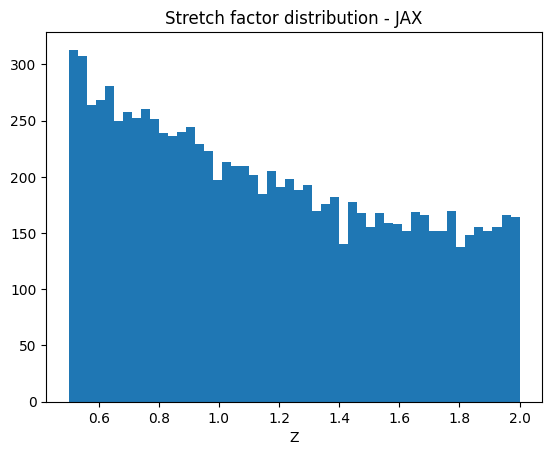


NumPy mean: 1.166
JAX mean:   1.159


In [14]:
key = jax.random.PRNGKey(0)

z_samples = sample_stretch_factor_jax(key, 10_000)

# Check 1: range
print(f"Min: {z_samples.min():.3f}")   # should be >= 0.5
print(f"Max: {z_samples.max():.3f}")   # should be <= 2.0

# Check 2: mean
print(f"Mean: {z_samples.mean():.3f}") # should be around 1.08-1.17

# Check 3: histogram shape - should decrease left to right
import matplotlib.pyplot as plt
plt.hist(z_samples, bins=50)
plt.title("Stretch factor distribution - JAX")
plt.xlabel("Z")
plt.show()

# Check 4: matches NumPy version statistically
rng = np.random.default_rng(0)
z_np = sample_stretch_factor(rng, 10_000)
print(f"\nNumPy mean: {z_np.mean():.3f}")
print(f"JAX mean:   {z_samples.mean():.3f}")
# Should be close to each other

In [15]:
@jax.jit
def gw_proposal_jax(walker_i, walker_j, z):
  return walker_j + z * (walker_i - walker_j)

In [16]:
wi = jnp.array([1.0, 2.0])
wj = jnp.array([3.0, 4.0])

print(gw_proposal_jax(wi, wj, 1.0))  # should be [1.0, 2.0]
print(gw_proposal_jax(wi, wj, 2.0))  # should be [-1.0, 0.0]
print(gw_proposal_jax(wi, wj, 0.5))  # should be [2.0, 3.0]

[1. 2.]
[-1.  0.]
[2. 3.]


In [62]:
@jax.jit
def gw_accept_jax(current_log_prob, proposal_log_prob, z, dim, key):
  log_a = (dim - 1) * jnp.log(z) + proposal_log_prob - current_log_prob
  log_u = jnp.log(jax.random.uniform(key))
  return log_u < log_a

In [63]:
key = jax.random.PRNGKey(0)

# Check 1: proposal much better - should be True
print(gw_accept_jax(-10.0, -0.1, 1.0, 2, key))

# Check 2: proposal much worse - should be False
print(gw_accept_jax(-0.1, -10.0, 1.0, 2, key))

# Check 3: when z=1 and dim=2, correction term vanishes
# should behave same as regular accept
log_alpha = (2-1) * jnp.log(1.0) + (-5.0) - (-5.0)
print(log_alpha)   # should be 0.0

True
False
0.0


In [24]:
@jax.jit
def select_complementary_jax(n_walkers, i, key):
    j = jax.random.randint(key, shape=(), minval=0, maxval=n_walkers - 1)
    return jnp.where(j >= i, j + 1, j)

In [25]:
# Check 1: never returns i
i = 5
keys = jax.random.split(jax.random.PRNGKey(0), 1000)
results = jax.vmap(lambda k: select_complementary_jax(10, 5, k))(keys)
print(f"i appears: {jnp.sum(results == i)}")    # should be 0

# Check 2: covers all other indices
print(f"Min: {results.min()}")                   # should be 0
print(f"Max: {results.max()}")                   # should be 9
print(f"Unique values: {jnp.unique(results)}")   # should be 0-9 excluding 5

# Check 3: works for edge cases
key = jax.random.PRNGKey(0)
print(select_complementary_jax(10, 0, key))   # should never be 0
print(select_complementary_jax(10, 9, key))   # should never be 9

i appears: 0
Min: 0
Max: 9
Unique values: [0 1 2 3 4 6 7 8 9]
4
3


In [64]:
@partial(jax.jit, static_argnums = (0, 2, 4))
def goodman_weare_jax(log_prob_fn, init_walkers, n_steps, key, n_walkers, a = 2.0):
  dim = int(init_walkers.shape[1])
  def update_one_walker(i, walkers, log_probs, key, a):
    key1, key2, key3 =jax.random.split(key, 3)
    comp_walker = select_complementary_jax(n_walkers, i, key1)
    z = sample_stretch_factor_jax(key2, 1, a)[0]
    proposal = gw_proposal_jax(walkers[i], walkers[comp_walker], z)
    prop_log_prob = log_prob_fn(proposal)
    accepted = gw_accept_jax(log_probs[i], prop_log_prob, z, dim, key3)
    new_pos = jnp.where(accepted, proposal, walkers[i])
    new_lp = jnp.where(accepted, prop_log_prob, log_probs[i])
    acc = jnp.where(accepted, 1, 0)
    return new_pos, new_lp, acc
  update_walkers = jax.vmap(update_one_walker, in_axes = (0, None, None, 0, None), out_axes = (0, 0, 0))
  def gw_step(carry, _):
    walkers, log_probs, key, acc_counter = carry
    new_key, *subkeys = jax.random.split(key, n_walkers + 1)
    subkeys = jnp.array(subkeys)
    new_walkers, new_log_probs, new_acc = update_walkers(jnp.arange(n_walkers), walkers, log_probs, subkeys, a)
    acc_counter = acc_counter + jnp.sum(new_acc)
    new_carry = (new_walkers, new_log_probs, new_key, acc_counter)
    return new_carry, new_walkers
  log_probs = jax.vmap(log_prob_fn)(init_walkers)
  init_carry = (init_walkers, log_probs, key, 0)
  (final_pos, final_lp, _, n_accepted), chain = lax.scan(gw_step, init_carry, xs = None, length = n_steps)
  return chain, n_accepted / (n_walkers * n_steps)


In [66]:
key = jax.random.PRNGKey(42)
rng = np.random.default_rng(42)
n_walkers = 50
dim = 2
init_walkers_jax = jax.random.normal(jax.random.PRNGKey(0), shape=(n_walkers, dim))
init_walkers_np  = np.array(init_walkers_jax)

# Walker position check
chain_gw_jax, _ = goodman_weare_jax(log_prob_jax, init_walkers_jax, 5, key, n_walkers)
print("Walker 0 position over 5 steps:")
for step in range(5):
    print(f"  Step {step}: {chain_gw_jax[step, 0, :]}")

# Full run
chain_gw_jax, accept_rate_jax = goodman_weare_jax(
    log_prob_jax, init_walkers_jax, 2_000, key, n_walkers
)

# Test 1: shape
print(f"\nChain shape: {chain_gw_jax.shape}")        # (2000, 50, 2)

# Test 2: acceptance rate
print(f"Acceptance rate: {accept_rate_jax:.2%}")     # 40-70%

# Test 3: sample mean
burnin = 200
flat_samples = chain_gw_jax[burnin:].reshape(-1, dim)
print(f"Sample mean: {flat_samples.mean(axis=0).round(3)}")  # close to [2.0, -1.0]

# Test 4: sample covariance
print(f"Sample cov:\n{jnp.cov(flat_samples.T).round(3)}")   # close to [[1.0, 0.8], [0.8, 1.0]]

# Test 5: compare with NumPy version
chain_gw_np, accept_rate_np = goodman_weare(
    log_prob, init_walkers_np, 2_000, rng
)
flat_samples_np = chain_gw_np[200:].reshape(-1, dim)
print(f"\nNumPy mean:  {flat_samples_np.mean(axis=0).round(3)}")
print(f"JAX mean:    {flat_samples.mean(axis=0).round(3)}")
print(f"\nNumPy acceptance rate: {accept_rate_np:.2%}")
print(f"JAX acceptance rate:   {accept_rate_jax:.2%}")

# Test 6: walker spread over time
print("\nWalker spread over time:")
for t in [0, 100, 500, 1000, 1999]:
    positions = chain_gw_jax[t]
    print(f"  Step {t}: mean={positions.mean(axis=0).round(2)}, std={positions.std(axis=0).round(2)}")

Walker 0 position over 5 steps:
  Step 0: [ 0.63107841 -1.53165621]
  Step 1: [ 0.63107841 -1.53165621]
  Step 2: [ 1.18595626 -2.3298761 ]
  Step 3: [ 1.18595626 -2.3298761 ]
  Step 4: [ 1.18595626 -2.3298761 ]

Chain shape: (2000, 50, 2)
Acceptance rate: 71.02%
Sample mean: [ 2.004 -1.015]
Sample cov:
[[0.993 0.796]
 [0.796 1.014]]

NumPy mean:  [ 2.007 -0.983]
JAX mean:    [ 2.004 -1.015]

NumPy acceptance rate: 71.60%
JAX acceptance rate:   71.02%

Walker spread over time:
  Step 0: mean=[ 0.28 -0.29], std=[1.14 1.21]
  Step 100: mean=[ 2.12 -0.97], std=[1.06 1.07]
  Step 500: mean=[ 2.18 -0.76], std=[0.99 1.07]
  Step 1000: mean=[ 1.96 -1.13], std=[0.95 0.95]
  Step 1999: mean=[ 2.16 -0.85], std=[0.97 0.95]


In [67]:
import time

n_walkers = 50
dim = 2
init_walkers_jax = jax.random.normal(jax.random.PRNGKey(0), shape=(n_walkers, dim))
init_walkers_np  = np.array(init_walkers_jax)

print(f"\n{'n_steps':<12} {'NumPy':>10} {'JAX GPU':>10} {'Speedup':>10}")
print("-" * 45)

for n_steps in [100, 500, 1_000, 2_000]:
    rng = np.random.default_rng(42)
    key = jax.random.PRNGKey(42)

    start = time.time()
    goodman_weare(log_prob, init_walkers_np, n_steps, rng)
    t_np = time.time() - start

    # warm up
    goodman_weare_jax(log_prob_jax, init_walkers_jax, n_steps, key, n_walkers)

    start = time.time()
    chain_jax, _ = goodman_weare_jax(log_prob_jax, init_walkers_jax, n_steps, key, n_walkers)
    chain_jax.block_until_ready()
    t_jax = time.time() - start

    print(f"{n_steps:<12} {t_np:>9.3f}s {t_jax:>9.3f}s {t_np/t_jax:>9.1f}x")


n_steps           NumPy    JAX GPU    Speedup
---------------------------------------------
100              8.554s     0.020s     436.0x
500             41.948s     0.086s     488.0x
1000            86.385s     0.137s     630.2x
2000           173.335s     0.142s    1218.5x
